<a href="https://colab.research.google.com/github/JorgeRf07/Diplomado-Redes-Neuronales-Artificiales/blob/main/Pr%C3%A1ctica_8_Implementaci%C3%B3n_de_Redes_Neuronales_en_Microsoft_Azure_Notebooks_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Importamo las librerias necesarias
import time
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical

In [2]:
#El siguiente código es para identificar la versión de TensorFlow y los dispositivos
#disponibles
print("Versión de TensorFlow:", tf.__version__)
dispositivos = tf.config.list_physical_devices()
print("Dispositivos disponibles:")
for dispositivo in dispositivos:
  print(dispositivo)

Versión de TensorFlow: 2.20.0
Dispositivos disponibles:
PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')


In [3]:
#Cargar el conjunto de datos MNIST
(X_train, y_train), (X_test, y_test) = mnist.load_data()

#MNIST contiene imágenes de dígitos escritos a mano. Cada imagen tiene un tamaño de
#28 x 28 píxeles y pertenece a una de diez clases posibles: los números del 0 al 9.

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


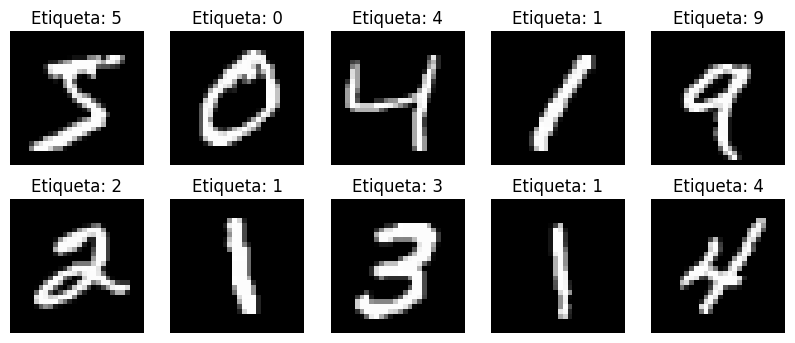

In [4]:
plt.figure(figsize=(10, 4))
for i in range(10):
  plt.subplot(2, 5, i + 1)
  plt.imshow(X_train[i], cmap="gray")
  plt.title("Etiqueta: " + str(y_train[i]))
  plt.axis("off")
plt.show()

In [5]:
print("Forma de X_train:", X_train.shape)
print("Forma de y_train:", y_train.shape)
print("Forma de X_test:", X_test.shape)
print("Forma de y_test:", y_test.shape)

# indican que hay 60,000 imágenes de entrenamiento de 28x28 píxeles,
#60,000 etiquetas de entrenamiento, 10,000 imágenes de prueba de 28x28 píxeles
#y 10,000 etiquetas de prueba.

Forma de X_train: (60000, 28, 28)
Forma de y_train: (60000,)
Forma de X_test: (10000, 28, 28)
Forma de y_test: (10000,)


In [6]:
#Los valores de los píxeles van de 0 a 255. Para facilitar el entrenamiento, se convierten a
#valores entre 0 y 1.
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

In [7]:
#Convertir etiquetas a formato categórico
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

In [8]:
#La red neuronal tendrá una arquitectura básica para clasificar imágenes de MNIST.
modelo = Sequential()
modelo.add(Flatten(input_shape=(28, 28)))
modelo.add(Dense(128, activation="relu"))
modelo.add(Dropout(0.2))
modelo.add(Dense(64, activation="relu"))
modelo.add(Dense(10, activation="softmax"))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


###En esta arquitectura:
• Flatten convierte la imagen de 28 x 28 píxeles en un vector.

• Dense crea capas completamente conectadas.

• Dropout ayuda a reducir el sobreajuste.

• softmax genera probabilidades para cada clase.

In [9]:
modelo.compile(
  optimizer="adam",
  loss="categorical_crossentropy",
  metrics=["accuracy"]
)

In [10]:
modelo.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
inicio = time.time()
historial = modelo.fit(
X_train,
y_train_cat,
epochs=10,
batch_size=128,
validation_split=0.2
)
fin = time.time()
tiempo_entrenamiento = fin - inicio
print("Tiempo de entrenamiento en G Colab:", tiempo_entrenamiento, "segundos")

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.8712 - loss: 0.4365 - val_accuracy: 0.9451 - val_loss: 0.1880
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9443 - loss: 0.1858 - val_accuracy: 0.9618 - val_loss: 0.1286
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9591 - loss: 0.1364 - val_accuracy: 0.9682 - val_loss: 0.1062
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9664 - loss: 0.1107 - val_accuracy: 0.9691 - val_loss: 0.0995
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9721 - loss: 0.0931 - val_accuracy: 0.9734 - val_loss: 0.0874
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9753 - loss: 0.0810 - val_accuracy: 0.9745 - val_loss: 0.0828
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9776 - loss: 0.0706 - val_accuracy: 0.9745 - val_loss: 0.0832
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9801 - loss: 0.0635 - val_accuracy: 0

In [12]:
perdida, exactitud = modelo.evaluate(X_test, y_test_cat)
print("Pérdida en prueba:", perdida)
print("Exactitud en prueba:", exactitud)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9779 - loss: 0.0727
Pérdida en prueba: 0.07269730418920517
Exactitud en prueba: 0.9779000282287598


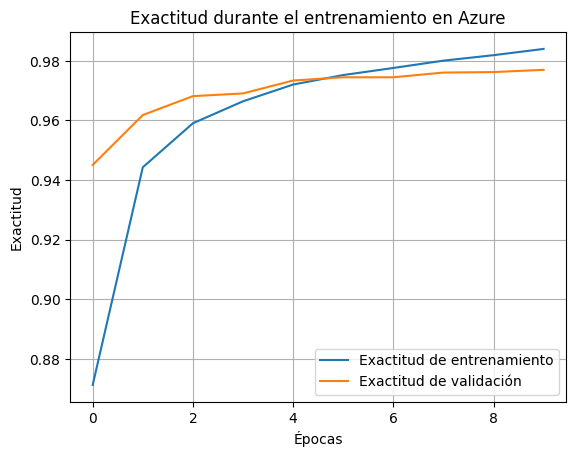

In [13]:
plt.plot(historial.history["accuracy"], label="Exactitud de entrenamiento")
plt.plot(historial.history["val_accuracy"], label="Exactitud de validación")
plt.title("Exactitud durante el entrenamiento en Azure")
plt.xlabel("Épocas")
plt.ylabel("Exactitud")
plt.legend()
plt.grid(True)
plt.show()

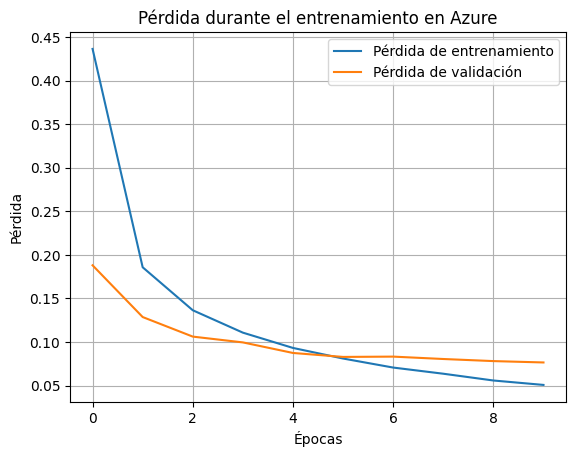

In [14]:
plt.plot(historial.history["loss"], label="Pérdida de entrenamiento")
plt.plot(historial.history["val_loss"], label="Pérdida de validación")
plt.title("Pérdida durante el entrenamiento en Azure")
plt.xlabel("Épocas")
plt.ylabel("Pérdida")
plt.legend()
plt.grid(True)
plt.show()

In [15]:
predicciones = modelo.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


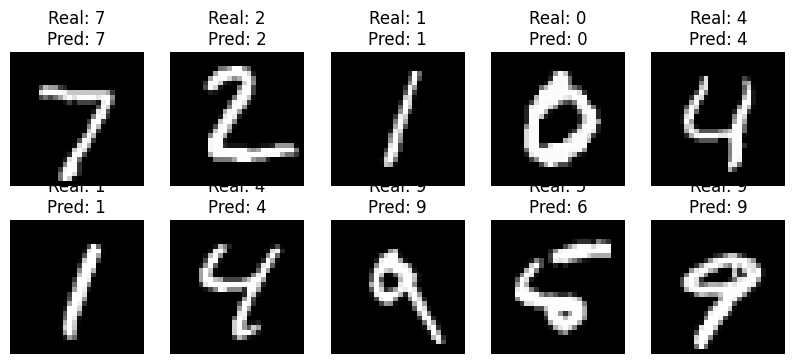

In [16]:
plt.figure(figsize=(10, 4))
for i in range(10):
  clase_real = y_test[i]
  clase_predicha = np.argmax(predicciones[i])
  plt.subplot(2, 5, i + 1)
  plt.imshow(X_test[i], cmap="gray")
  plt.title(
    "Real: " + str(clase_real) +
    "\nPred: " + str(clase_predicha)
  )
  plt.axis("off")
plt.show()


###Hardware utilizado:
Google Colab/VSC

###Tiempo de entrenamiento:
14.43010687828064 segundos

###Exactitud en prueba:
0.9789999723434448

###Pérdida en prueba:
0.07323097437620163

1. ¿Qué es Microsoft Azure?
Es una plataforma de servicios en la nube que permite crear, administrar y ejecutar diferentes soluciones tecnológicas, proporciona los recursos de cómputo necesarios para desarrollar y entrenar modelos de inteligencia artificial sin depender completamente de una computadora local.

2. ¿Qué es Azure Machine Learning?
Es un servicio de Microsoft Azure orientado al desarrollo, entrenamiento, evaluación y despliegue de modelos de aprendizaje automático. Permite trabajar con notebooks de Python y utilizar instancias de cómputo en la nube para desarrollar proyectos de ciencia de datos e inteligencia artificial.

3. ¿Qué función cumplen los notebooks dentro de Azure Machine Learning?
Permiten escribir y ejecutar código Python de manera interactiva.

4. ¿Qué diferencia existe entre Azure Machine Learning, Google Colab y Kaggle Notebooks?
Las tres plataformas permiten ejecutar código y entrenar modelos en la nube.
•	Azure Machine Learning: está orientado a un entorno más profesional y permite configurar recursos de cómputo, incluyendo máquinas virtuales e instancias con GPU.
•	Google Colab: proporciona un entorno accesible para realizar prácticas y experimentación con modelos de aprendizaje automático.
•	Kaggle Notebooks: ofrece un entorno en la nube enfocado principalmente en prácticas, experimentación y trabajo con datos.

5. ¿Qué conjunto de datos se utilizó en esta práctica?
Se utilizó el conjunto de datos MNIST, que contiene imágenes de dígitos escritos a mano del 0 al 9.
Cada imagen tiene un tamaño de 28 × 28 píxeles y pertenece a una de diez clases posibles.

6. ¿Qué tipo de problema se resolvió?
Problema de clasificación de imágenes.
La red neuronal recibe una imagen de un dígito escrito a mano y debe determinar a cuál de las diez clases, del 0 al 9, pertenece. Busca clasificar los datos del conjunto MNIST.

7. ¿Qué hardware utilizó Azure durante el entrenamiento?
Azure utilizó [CPU/GPU según la ejecución realizada].

8. ¿Qué hardware utilizó Google Colab o Kaggle durante el entrenamiento?
Google Colab/Kaggle utilizó [CPU/GPU según la ejecución realizada].

9. ¿Qué plataforma obtuvo menor tiempo de entrenamiento?
La plataforma que obtuvo menor tiempo fue Azure.

10. ¿La exactitud cambió entre plataformas?
La exactitud puede ser similar entre las plataformas cuando se utiliza el mismo modelo y el mismo número de épocas.

11. ¿Por qué el tiempo de entrenamiento puede variar entre Azure, Colab y Kaggle?
El tiempo puede variar debido principalmente a:
•	El tipo de hardware utilizado.
•	Si se utiliza CPU o GPU.
•	La cantidad de memoria disponible.
•	La carga del servidor.
•	La configuración del entorno de ejecución.
•	Los recursos de cómputo asignados a cada usuario.

12. ¿Qué ventajas tiene usar plataformas en la nube para entrenar redes neuronales?
Las plataformas en la nube ofrecen varias ventajas:
•	Permiten entrenar modelos sin depender completamente del hardware de una computadora personal.
•	Proporcionan recursos de cómputo que pueden ser más potentes que los disponibles localmente.
•	Permiten utilizar GPU cuando están disponibles.
•	Facilitan el desarrollo mediante notebooks.
•	Permiten experimentar con redes neuronales y otros modelos de inteligencia artificial.
•	Hacen posible comparar diferentes configuraciones y plataformas.
•	Azure Machine Learning permite utilizar recursos de cómputo configurables para proyectos de ciencia de datos e inteligencia artificial.
